### Imports

In [1]:
import torch
import torch.nn as nn

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

### load MNIST dataset

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="../data",
    train = True,
    download = True,
    transform = transform
)

test_dataset = datasets.MNIST(
    root = "../data",
    train = False,
    download = True,
    transform = transform
)

### Create DataLoaders

In [3]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

### Verify batch shapes

In [4]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


### ANN accepts only two dimensions (batch_size, features)

In [5]:
images = images.view(images.size(0),-1)
# view() reshapes a tensor without changing its data

print(images.shape)

torch.Size([64, 784])


### Building the ANN class

In [6]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784,128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128,10)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

In [7]:
model = ANN()
print(model)

ANN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [8]:
for name,param in model.named_parameters():
    print(name, param.shape)

fc1.weight torch.Size([128, 784])
fc1.bias torch.Size([128])
fc2.weight torch.Size([10, 128])
fc2.bias torch.Size([10])


In [9]:
output = model(images)
print(output.shape)

torch.Size([64, 10])


In [10]:
print(output[0])

tensor([ 0.1633, -0.0447, -0.1188, -0.0176,  0.0985,  0.0151,  0.0596, -0.1569,
        -0.0161,  0.0213], grad_fn=<SelectBackward0>)


In [11]:
prediction = torch.argmax(output, dim=1)

print(prediction[:10])

tensor([0, 0, 0, 0, 5, 0, 0, 0, 0, 0])


In [12]:
print(labels[:10])

tensor([3, 9, 3, 8, 2, 1, 0, 1, 5, 5])


### Loss function and optimizer

In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr = 0.01
)

In [14]:
num_epochs = 3

for epoch in range(num_epochs):

    running_loss = 0.0

    for images, labels in train_loader:
        
        # flatten the images
        images = images.view(images.size(0),-1)

        # create old gradients
        optimizer.zero_grad()

        # Forward Pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update Weights
        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch [1/3], Loss: 1.2488
Epoch [2/3], Loss: 0.4987
Epoch [3/3], Loss: 0.3939


In [15]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in train_loader:

        images = images.view(images.size(0), -1)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Training Accuracy: {accuracy:.2f}%")

Training Accuracy: 89.79%


In [16]:
model_adam = ANN()

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model_adam.parameters(),
    lr = 0.1
)

In [18]:
num_epochs = 3

for epoch in range(num_epochs):

    running_loss = 0.0

    for images, labels in train_loader:
        
        # flatten the images
        images = images.view(images.size(0),-1)

        # Reset gradients before backpropagation
        optimizer.zero_grad()

        # Forward Pass
        outputs = model_adam(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update Weights
        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch [1/3], Loss: 0.8444
Epoch [2/3], Loss: 0.8476
Epoch [3/3], Loss: 0.8984


In [19]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in train_loader:

        images = images.view(images.size(0), -1)

        outputs = model_adam(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Training Accuracy: {accuracy:.2f}%")

Training Accuracy: 70.87%


In [20]:
def train_model(lr):

    model = ANN()

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    num_epochs = 3

    print(f"\nTraining with Learning Rate = {lr}")

    for epoch in range(num_epochs):

        running_loss = 0.0

        for images, labels in train_loader:

            images = images.view(images.size(0), -1)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Loss: {running_loss/len(train_loader):.4f}"
        )

    return model

In [21]:
model_lr_01 = train_model(0.1)


Training with Learning Rate = 0.1
Epoch [1/3] Loss: 1.0656
Epoch [2/3] Loss: 0.9675
Epoch [3/3] Loss: 0.9667


In [22]:
model_lr_01 = train_model(0.01)


Training with Learning Rate = 0.01
Epoch [1/3] Loss: 0.2224
Epoch [2/3] Loss: 0.1276
Epoch [3/3] Loss: 0.1109


In [23]:
model_lr_01 = train_model(0.001)


Training with Learning Rate = 0.001
Epoch [1/3] Loss: 0.3471
Epoch [2/3] Loss: 0.1592
Epoch [3/3] Loss: 0.1084


## Training and validation curves

In [24]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset)-train_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size]
)

In [25]:
print(len(train_subset))
print(len(val_subset))

48000
12000


In [26]:
train_loader = DataLoader(
    train_subset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=64,
    shuffle=False
)

In [27]:
train_losses = []
val_losses = []

## Training And Validation

In [28]:
model = ANN()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.001
)

In [29]:
num_epochs = 5

for epoch in range(num_epochs):

    # ------------------
    # TRAINING
    # ------------------

    model.train()

    running_train_loss = 0.0

    for images, labels in train_loader:

        images = images.view(images.size(0), -1)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = (
        running_train_loss / len(train_loader)
    )

    train_losses.append(avg_train_loss)

    # ------------------
    # VALIDATION
    # ------------------

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.view(images.size(0), -1)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    avg_val_loss = (
        running_val_loss / len(val_loader)
    )

    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss = {avg_train_loss:.4f}, "
        f"Val Loss = {avg_val_loss:.4f}"
    )

Epoch 1: Train Loss = 0.3770, Val Loss = 0.2322
Epoch 2: Train Loss = 0.1728, Val Loss = 0.1685
Epoch 3: Train Loss = 0.1220, Val Loss = 0.1294
Epoch 4: Train Loss = 0.0933, Val Loss = 0.1235
Epoch 5: Train Loss = 0.0740, Val Loss = 0.1063


# Implementing Dropout

In [30]:
class ANN_Dropout(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.5)

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.fc1(x)

        x = self.relu(x)

        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [31]:
model_do = ANN_Dropout()

In [32]:
optimizer = torch.optim.Adam(
    model_do.parameters(),
    lr=0.001
)

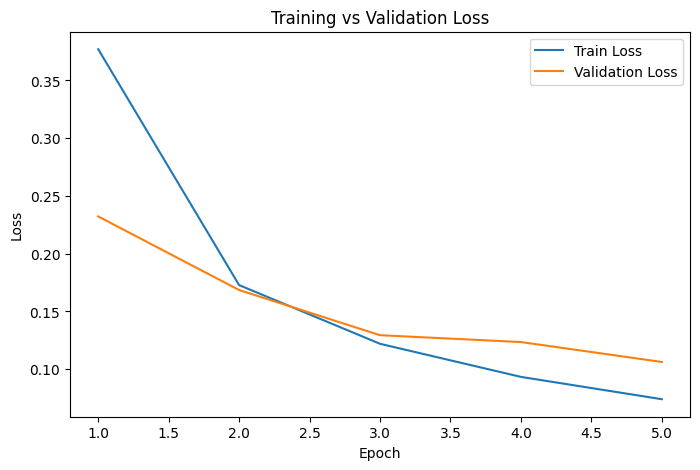

In [33]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [34]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

num_epochs = 5

for epoch in range(num_epochs):

    # =====================
    # TRAINING
    # =====================

    model_do.train()

    running_train_loss = 0.0

    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        images = images.view(images.size(0), -1)

        optimizer.zero_grad()

        outputs = model_do(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total_train += labels.size(0)

        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(train_loader)

    train_accuracy = (
        100 * correct_train / total_train
    )

    train_losses.append(avg_train_loss)

    train_accuracies.append(train_accuracy)

    # =====================
    # VALIDATION
    # =====================

    model_do.eval()

    running_val_loss = 0.0

    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.view(images.size(0), -1)

            outputs = model_do(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total_val += labels.size(0)

            correct_val += (predicted == labels).sum().item()

    avg_val_loss = running_val_loss / len(val_loader)

    val_accuracy = (
        100 * correct_val / total_val
    )

    val_losses.append(avg_val_loss)

    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {avg_train_loss:.4f} "
        f"Val Loss: {avg_val_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/5] Train Loss: 0.4978 Val Loss: 0.2518 Train Acc: 85.95% Val Acc: 92.70%
Epoch [2/5] Train Loss: 0.2678 Val Loss: 0.1895 Train Acc: 92.34% Val Acc: 94.72%
Epoch [3/5] Train Loss: 0.2156 Val Loss: 0.1618 Train Acc: 93.62% Val Acc: 95.43%
Epoch [4/5] Train Loss: 0.1877 Val Loss: 0.1421 Train Acc: 94.43% Val Acc: 95.86%
Epoch [5/5] Train Loss: 0.1706 Val Loss: 0.1327 Train Acc: 95.03% Val Acc: 96.01%


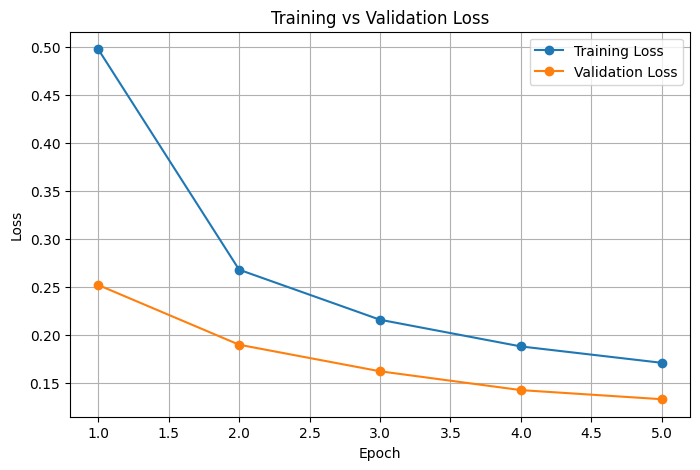

In [35]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    train_losses,
    marker='o',
    label='Training Loss'
)

plt.plot(
    epochs,
    val_losses,
    marker='o',
    label='Validation Loss'
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

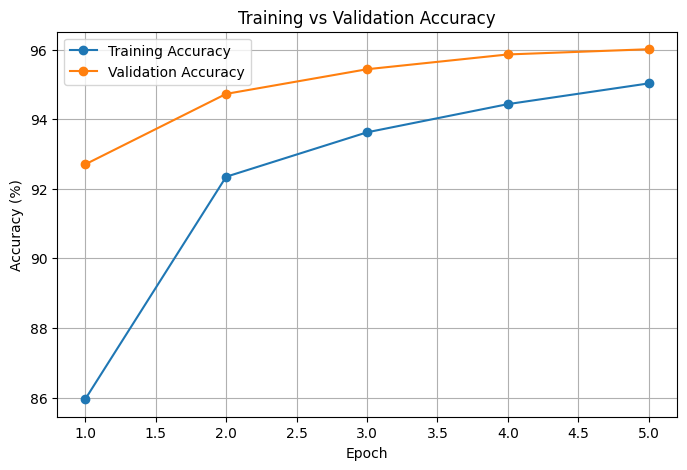

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    train_accuracies,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    epochs,
    val_accuracies,
    marker='o',
    label='Validation Accuracy'
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.legend()

plt.grid(True)

plt.show()

## Implementing BatchNorm

In [37]:
class ANN_BatchNorm(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)

        self.bn1 = nn.BatchNorm1d(128)

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.5)

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.fc1(x)

        x = self.bn1(x)

        x = self.relu(x)

        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [38]:
model_bn = ANN_BatchNorm()

In [39]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_bn.parameters(),
    lr=0.001
)

In [46]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

num_epochs = 5

for epoch in range(num_epochs):

    # =====================
    # TRAINING
    # =====================

    model_bn.train()

    running_train_loss = 0.0

    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        images = images.view(images.size(0), -1)

        optimizer.zero_grad()

        outputs = model_bn(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total_train += labels.size(0)

        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(train_loader)

    train_accuracy = (
        100 * correct_train / total_train
    )

    train_losses.append(avg_train_loss)

    train_accuracies.append(train_accuracy)

    # =====================
    # VALIDATION
    # =====================

    model_bn.eval()

    running_val_loss = 0.0

    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.view(images.size(0), -1)

            outputs = model_bn(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total_val += labels.size(0)

            correct_val += (predicted == labels).sum().item()

    avg_val_loss = running_val_loss / len(val_loader)

    val_accuracy = (
        100 * correct_val / total_val
    )

    val_losses.append(avg_val_loss)

    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {avg_train_loss:.4f} "
        f"Val Loss: {avg_val_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/5] Train Loss: 0.1639 Val Loss: 0.1164 Train Acc: 95.10% Val Acc: 96.68%
Epoch [2/5] Train Loss: 0.1583 Val Loss: 0.1128 Train Acc: 95.24% Val Acc: 96.82%
Epoch [3/5] Train Loss: 0.1503 Val Loss: 0.1092 Train Acc: 95.39% Val Acc: 96.86%
Epoch [4/5] Train Loss: 0.1433 Val Loss: 0.1093 Train Acc: 95.58% Val Acc: 96.93%
Epoch [5/5] Train Loss: 0.1396 Val Loss: 0.1065 Train Acc: 95.67% Val Acc: 96.93%


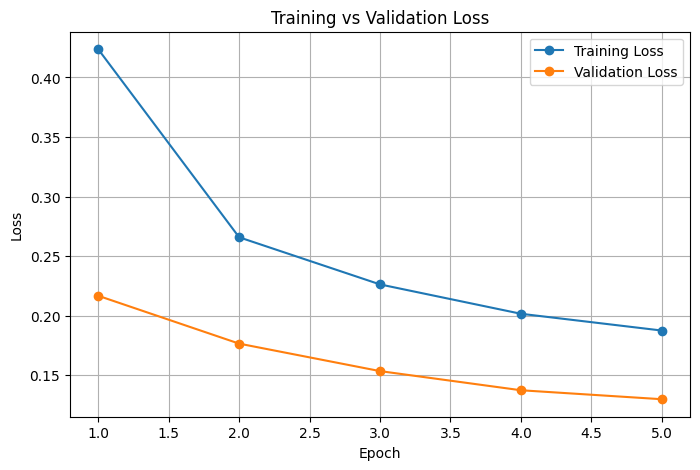

In [41]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    train_losses,
    marker='o',
    label='Training Loss'
)

plt.plot(
    epochs,
    val_losses,
    marker='o',
    label='Validation Loss'
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

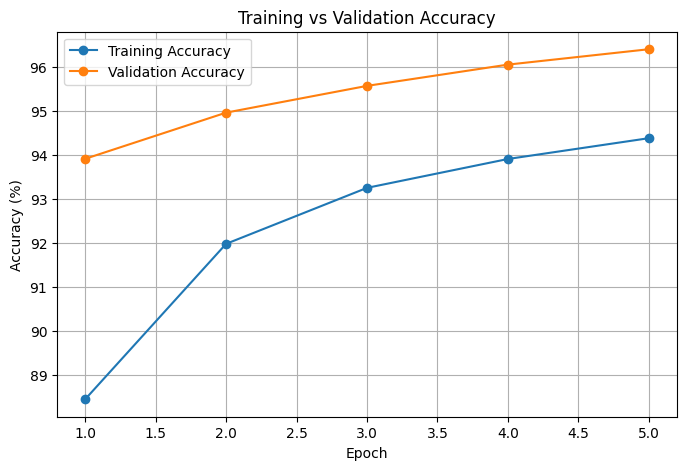

In [42]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    train_accuracies,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    epochs,
    val_accuracies,
    marker='o',
    label='Validation Accuracy'
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.legend()

plt.grid(True)

plt.show()

In [43]:
torch.save(
    model_bn.state_dict(),
    "../models/mnist_ann_batchnorm_dropout.pth"
)

print("Model Saved Sucessfully!")

Model Saved Sucessfully!


In [44]:
torch.save({
    "epoch": epoch,
    "model_state_dict": model_bn.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "val_loss": avg_val_loss
},
"../models/checkpoint.pth")

In [47]:
import os

print(
    os.path.exists(
        "../models/mnist_ann_batchnorm_dropout.pth"
    )
)

True


In [48]:
import os

print(os.getcwd())

C:\Users\anura\Desktop\Deep-Learning-Lab\notebooks


In [49]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if file.endswith(".pth"):
            print(os.path.join(root, file))

..\models\checkpoint.pth
..\models\mnist_ann_batchnorm_dropout.pth
..\venv\Lib\site-packages\distutils-precedence.pth
